# 02c — XGBoost (PreTec21 → Tec21)
## Equipo 7

Búsqueda de hiperparámetros, entrenamiento en PreTec21 y evaluación cross-regime en Tec21. Incluye comparativa contra baseline self-trained. El notebook omite pasos si XGBoost no está disponible.

## 1. Setup e Importaciones

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import time, os
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine as cosine_dist

# Clustering
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score, davies_bouldin_score
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.impute           import SimpleImputer

# Modelos supervisados
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import (
    StratifiedKFold, cross_validate, train_test_split
)
from sklearn.metrics          import (
    roc_auc_score, recall_score, f1_score, precision_score,
    roc_curve, precision_recall_curve
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('   XGBoost disponible:', xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print('  XGBoost no disponible')

try:
    import shap
    SHAP_AVAILABLE = True
    print('   SHAP disponible:', shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print(' SHAP no disponible')

SEED = 42
np.random.seed(SEED)
print('\n   Librerías cargadas')

✓ XGBoost disponible: 3.2.0
✓ SHAP disponible: 0.51.0

✓ Librerías cargadas


## 2. Configuración

In [2]:
DATASET_MODE   = 'imputed'
DATA_DIR       = Path('../data')
IMG_DIR        = Path('../results/figures'); IMG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR      = Path('../results/tables');  TABLE_DIR.mkdir(parents=True, exist_ok=True)

PRETEC21_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEC21_GENS     = ['AD19', 'AD20']
TARGET         = 'retention'

K_CLUSTERS     = 4
MIN_SILHOUETTE = 0.30
MAX_DB         = 1.50
MIN_AUC        = 0.60

# Umbral de distancia coseno para match de clusters
# < 0.15 → match alto | 0.15-0.35 → match parcial | > 0.35 → sin match
MATCH_HIGH     = 0.15
MATCH_PARTIAL  = 0.35

print(f'K_CLUSTERS    : {K_CLUSTERS}')
print(f'PreTec21 gens : {PRETEC21_GENS}')
print(f'Tec21 gens    : {TEC21_GENS}')
print(f'NOTA: En este notebook K-Means se entrena INDEPENDIENTEMENTE en cada régimen.')

K_CLUSTERS    : 4
PreTec21 gens : ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
Tec21 gens    : ['AD19', 'AD20']
NOTA: En este notebook K-Means se entrena INDEPENDIENTEMENTE en cada régimen.


## 3. Carga del Dataset

In [3]:
csv_path = DATA_DIR / 'dataset_imputed.csv'
df_raw   = pd.read_csv(csv_path, low_memory=False)
print(f'✓ {csv_path.name} cargado  →  {df_raw.shape}')

print(f'\nDistribución por generación:')
print(df_raw['generation'].value_counts().sort_index().to_string())

print(f'\nDistribución target:')
counts = df_raw[TARGET].value_counts()
print(f'  Retuvo  (1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df_raw)*100:.1f}%)')
print(f'  Desertó (0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df_raw)*100:.1f}%)')

✓ dataset_imputed.csv cargado  →  (77517, 58)

Distribución por generación:
generation
AD14    10143
AD15    10041
AD16    10742
AD17    10788
AD18    11296
AD19    12199
AD20    12308

Distribución target:
  Retuvo  (1): 70,704  (91.2%)
  Desertó (0):  6,813  (8.8%)


## 4. Feature Engineering

In [4]:
from sklearn.preprocessing import LabelEncoder

def norm_admission_test(val):
    if pd.isna(val): return np.nan
    try:
        f = float(val)
        return max(0.0, (f - 400) / 1200.0) if f > 100 else f / 100.0
    except: return np.nan

EDU_ORD = {
    'No information': -1, 'MISSING': -1,
    'No degree': 0, 'Undergraduate degree': 1, 'Master degree': 2, 'PhD': 3,
}

df = df_raw.copy()
if 'level' in df.columns:
    df = df[df['level'] == 'Undergraduate'].copy()
    print(f'Filtrado nivel universitario: {len(df):,} registros')

DROP_COLS = [
    'student.id', 'level', 'average.first.period', 'failed.subject.first.period',
    'dropped.subject.first.period', 'dropout.semester', 'program', 'id.school.origin',
    'scholarship.type', 'school.cost', 'parents.exatec', 'father.exatec', 'mother.exatec',
    'father.education.complete', 'father.education.summary',
    'mother.education.complete', 'mother.education.summary',
    'scholarship.perc', 'loan.perc', 'educational.model',
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# ── admission_test_norm ───────────────────────────────────────────────────
if 'admission.test' in df.columns:
    df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test)
    df.drop(columns=['admission.test'], inplace=True)
if 'admission_test_norm' not in df.columns:
    df['admission_test_norm'] = np.nan
df['admission_test_norm'].fillna(df['admission_test_norm'].median(), inplace=True)

# ── first_gen_enc ─────────────────────────────────────────────────────────
def enc_first_gen(v):
    s = str(v).strip() if pd.notna(v) else ''
    return 1 if s == 'Yes' else (0 if s == 'No' else -1)
if 'first.generation' in df.columns:
    df['first_gen_enc'] = df['first.generation'].apply(enc_first_gen)
    df.drop(columns=['first.generation'], inplace=True)
elif 'first_gen_enc' not in df.columns:
    df['first_gen_enc'] = -1

# ── educ_padres_max ───────────────────────────────────────────────────────
if 'max.degree.parents' in df.columns:
    df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(-1).astype(int)
    df.drop(columns=['max.degree.parents'], inplace=True)
elif 'educ_padres_max' not in df.columns:
    df['educ_padres_max'] = -1

# ── apoyo_financiero ──────────────────────────────────────────────────────
if 'total.scholarship.loan' in df.columns:
    df.rename(columns={'total.scholarship.loan': 'apoyo_financiero'}, inplace=True)
elif 'apoyo_financiero' not in df.columns:
    df['apoyo_financiero'] = 0.0

# ── has_extracurriculars ──────────────────────────────────────────────────
if 'has_extracurriculars' not in df.columns:
    df['has_extracurriculars'] = df['has_life_activities'].copy() if 'has_life_activities' in df.columns else 0

ACTIVITY_COLS = ['physical.education','cultural.diffusion','student.society',
                 'total.life.activities','athletic.sports','art.culture',
                 'student.society.leadership','life.work.mentoring','wellness.activities']
df.drop(columns=[c for c in ACTIVITY_COLS + ['has_life_activities'] if c in df.columns], inplace=True)

# ── variables demográficas y socioeconómicas ──────────────────────────────
if 'gender' in df.columns:
    df['is_male'] = df['gender'].map({'Male':1,'Female':0}).fillna(0).astype(int)
    df.drop(columns=['gender'], inplace=True)
elif 'is_male' not in df.columns:
    df['is_male'] = 0

if 'tec.no.tec' in df.columns:
    df['estuvo_prepa_tec'] = df['tec.no.tec'].map({'TEC':1,'NO TEC':0}).fillna(0).astype(int)
    df.drop(columns=['tec.no.tec'], inplace=True)
elif 'estuvo_prepa_tec' not in df.columns:
    df['estuvo_prepa_tec'] = 0

if 'socioeconomic.level' in df.columns:
    df['socioec_enc'] = df['socioeconomic.level'].map(
        {**{'No information':0,'MISSING':0},**{f'Level {i}':i for i in range(1,8)}}).fillna(0).astype(int)
    df.drop(columns=['socioeconomic.level'], inplace=True)
elif 'socioec_enc' not in df.columns:
    df['socioec_enc'] = 0

if 'social.lag' in df.columns:
    df['social_lag_enc'] = df['social.lag'].map(
        {'No information':0,'MISSING':0,'Low':1,'Medium':2,'High':3}).fillna(0).astype(int)
    df.drop(columns=['social.lag'], inplace=True)
elif 'social_lag_enc' not in df.columns:
    df['social_lag_enc'] = 0

if 'school' in df.columns:
    le_school = LabelEncoder()
    df['school_enc'] = le_school.fit_transform(df['school'].fillna('Unknown').astype(str))
    df.drop(columns=['school'], inplace=True)
elif 'school_enc' not in df.columns:
    df['school_enc'] = 0

if 'region' in df.columns:
    le_region = LabelEncoder()
    df['region_enc'] = le_region.fit_transform(df['region'].fillna('Unknown').astype(str))
    df.drop(columns=['region'], inplace=True)
elif 'region_enc' not in df.columns:
    df['region_enc'] = 0

if 'foreign' in df.columns:
    foreign_dummies = pd.get_dummies(df['foreign'], prefix='foreign', drop_first=True, dtype=int)
    df = pd.concat([df, foreign_dummies], axis=1)
    df.drop(columns=['foreign'], inplace=True)

df.drop(columns=[c for c in ['zone.type'] if c in df.columns], inplace=True)

print(f'\n✓ Feature engineering completado. Shape: {df.shape}')

Filtrado nivel universitario: 77,517 registros

✓ Feature engineering completado. Shape: (77517, 29)


## 5. Segmentación por Régimen

In [5]:
df_pre = df[df['generation'].isin(PRETEC21_GENS)].copy().reset_index(drop=True)
df_tec = df[df['generation'].isin(TEC21_GENS)].copy().reset_index(drop=True)

print(f'PreTec21 (AD14–AD18): {len(df_pre):,} estudiantes  |  Deserción: {(df_pre[TARGET]==0).mean()*100:.1f}%')
print(f'Tec21    (AD19–AD20): {len(df_tec):,} estudiantes  |  Deserción: {(df_tec[TARGET]==0).mean()*100:.1f}%')

PreTec21 (AD14–AD18): 53,010 estudiantes  |  Deserción: 8.8%
Tec21    (AD19–AD20): 24,507 estudiantes  |  Deserción: 8.7%


## 8. Features y Split para Modelos Supervisados

In [6]:
FEATURE_COLS_CANDIDATES = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero',
    'has_extracurriculars', 'has_physical', 'has_cultural', 'has_social',
    'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc',
    'age', 'is_male', 'estuvo_prepa_tec',
    'foreign_Yes: Foreigner', 'foreign_Yes: National',
    'school_enc', 'region_enc',
    'first_gen_present', 'parents_edu_present', 'took_admission_test',
    'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data',
]
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model'}
FEATURE_COLS = [c for c in FEATURE_COLS_CANDIDATES if c in df.columns and c not in EXCLUDE]
seen = set(); FEATURE_COLS = [c for c in FEATURE_COLS if c not in seen and not seen.add(c)]
print(f'Features para modelos supervisados ({len(FEATURE_COLS)}): {FEATURE_COLS}')

def make_split(df_regime, feature_cols, target=TARGET, seed=SEED):
    cols = [c for c in feature_cols if c in df_regime.columns]
    X    = df_regime[cols].values.astype(float)
    y    = df_regime[target].values.astype(int)
    imp  = SimpleImputer(strategy='median', keep_empty_features=True)
    X    = imp.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    return X_tr, X_te, y_tr, y_te, cols, imp

X_tr_pre, X_te_pre, y_tr_pre, y_te_pre, feat_pre, imp_pre = make_split(df_pre, FEATURE_COLS)
X_tr_tec, X_te_tec, y_tr_tec, y_te_tec, feat_tec, imp_tec = make_split(df_tec, FEATURE_COLS)
print(f'\nPreTec21  train: {X_tr_pre.shape}  test: {X_te_pre.shape}')
print(f'Tec21     train: {X_tr_tec.shape}  test: {X_te_tec.shape}')

Features para modelos supervisados (26): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc', 'age', 'is_male', 'estuvo_prepa_tec', 'foreign_Yes: Foreigner', 'foreign_Yes: National', 'school_enc', 'region_enc', 'first_gen_present', 'parents_edu_present', 'took_admission_test', 'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data']

PreTec21  train: (42408, 26)  test: (10602, 26)
Tec21     train: (19605, 26)  test: (4902, 26)


In [7]:
from sklearn.metrics import precision_recall_curve

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, feat_cols,
                   threshold=None, n_bootstrap=200, seed=SEED):
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:, 1] if has_proba else None
    if threshold is None and has_proba:
        skf_tmp = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
        oof = np.zeros(len(X_tr))
        for tr_i, va_i in skf_tmp.split(X_tr, y_tr):
            model.fit(X_tr[tr_i], y_tr[tr_i])
            oof[va_i] = model.predict_proba(X_tr[va_i])[:, 1]
        model.fit(X_tr, y_tr)
        # FIX: optimizar umbral para clase MINORITARIA (Desertor=0)
        # sklearn trata clase 1 como positiva por defecto; invertimos para clase 0
        oof_dropout = 1.0 - oof  # P(Desertor)
        prec_oof, rec_oof, thr_oof = precision_recall_curve(y_tr, oof_dropout, pos_label=0)
        f1_oof    = 2*prec_oof*rec_oof/(prec_oof+rec_oof+1e-8)
        thr_best  = float(thr_oof[np.argmax(f1_oof[:-1])])
        threshold = 1.0 - thr_best  # convertir de vuelta a threshold sobre P(Retenido)
    y_pred = (y_proba >= threshold).astype(int) if (threshold is not None and has_proba) \
             else model.predict(X_te)
    auc  = roc_auc_score(y_te, y_proba) if has_proba else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, pos_label=0, zero_division=0)  # F1 para Desertor (clase minoritaria)
    rng  = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_te), len(y_te))
        if y_proba is not None and len(np.unique(y_te[idx])) > 1:
            aucs.append(roc_auc_score(y_te[idx], y_proba[idx]))
    ci_lo, ci_hi = (np.percentile(aucs, [2.5,97.5]) if aucs else (auc, auc))
    thr_str = f'{threshold:.2f}' if threshold is not None else 'N/A'
    result = dict(model=model_name, auc=auc, ci_lo=ci_lo, ci_hi=ci_hi,
                  recall=rec, precision=prec, f1=f1, threshold=threshold,
                  y_proba=y_proba, y_pred=y_pred, feat_cols=feat_cols)
    print(f'  {model_name:<28} AUC={auc:.3f} [{ci_lo:.3f},{ci_hi:.3f}]  '
          f'Recall={rec:.3f}  F1={f1:.3f}  thr={thr_str}')
    return result

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


In [8]:
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                              roc_curve, auc as sk_auc,
                              precision_recall_curve, average_precision_score)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✓ XGBoost:', xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print('  XGBoost no disponible')

if XGB_AVAILABLE:
    spw = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    xgb_param_dist = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
    }
    xgb_base   = xgb.XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                                    random_state=SEED, n_jobs=-1, verbosity=0)
    xgb_search = RandomizedSearchCV(
        xgb_base, xgb_param_dist, n_iter=30, scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        random_state=SEED, n_jobs=-1, verbose=0
    )
    xgb_search.fit(X_tr_pre, y_tr_pre)
    best_xgb_params = xgb_search.best_params_
    print('✓ Mejores parámetros XGB:')
    for k, v in sorted(best_xgb_params.items()):
        print(f'    {k}: {v}')
    print(f'  CV AUC (media): {xgb_search.best_score_:.4f}')
else:
    best_xgb_params = {
        'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8
    }
    print('Usando hiperparámetros por defecto.')


✓ XGBoost: 3.2.0
✓ Mejores parámetros XGB:
    colsample_bytree: 0.7
    learning_rate: 0.05
    max_depth: 3
    n_estimators: 200
    subsample: 0.7
  CV AUC (media): 0.6922


In [10]:
if XGB_AVAILABLE:
    spw = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    xgb_model = xgb.XGBClassifier(**best_xgb_params, scale_pos_weight=spw,
                                   eval_metric='logloss', random_state=SEED,
                                   n_jobs=-1, verbosity=0)
    print('═══ XGBoost (hiperparámetros optimizados) ═══')
    res_xgb = evaluate_model(xgb_model, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                             'XGBoost', feat_pre)
    results_final = [res_xgb]
    xgb_global = xgb_model

    print('\n═══ Baseline: XGB entrenado en Tec21 (self) ═══')
    xgb_self = xgb.XGBClassifier(**best_xgb_params, scale_pos_weight=spw,
                                   eval_metric='logloss', random_state=SEED,
                                   n_jobs=-1, verbosity=0)
    res_tec_self = evaluate_model(xgb_self, X_tr_tec, X_te_tec, y_tr_tec, y_te_tec,
                                  'XGB_Tec21_self', feat_tec)
    print(f'\nDegradación cross-regime: ΔAUC = {res_xgb["auc"] - res_tec_self["auc"]:+.3f}')
else:
    print('XGBoost no disponible — omitiendo entrenamiento.')
    results_final = []


═══ XGBoost (hiperparámetros optimizados) ═══
  XGBoost                      AUC=0.663 [0.635,0.686]  Recall=0.800  F1=0.243  thr=0.38

═══ Baseline: XGB entrenado en Tec21 (self) ═══
  XGB_Tec21_self               AUC=0.690 [0.663,0.711]  Recall=0.867  F1=0.242  thr=0.41

Degradación cross-regime: ΔAUC = -0.027


In [11]:
from sklearn.model_selection import cross_val_score
if XGB_AVAILABLE:
    cv_skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    spw      = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    scores   = cross_val_score(
        xgb.XGBClassifier(**best_xgb_params, scale_pos_weight=spw,
                           eval_metric='logloss', random_state=SEED,
                           n_jobs=-1, verbosity=0),
        X_tr_pre, y_tr_pre, cv=cv_skf, scoring='roc_auc', n_jobs=-1
    )
    print(f'5-fold CV AUC (XGBoost, PreTec21): {scores.mean():.4f} ± {scores.std():.4f}')
    cv_results = {'XGBoost': scores}


5-fold CV AUC (XGBoost, PreTec21): 0.6922 ± 0.0149


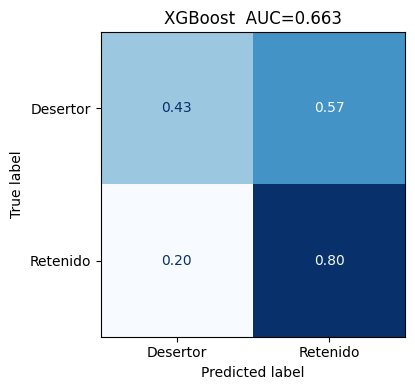

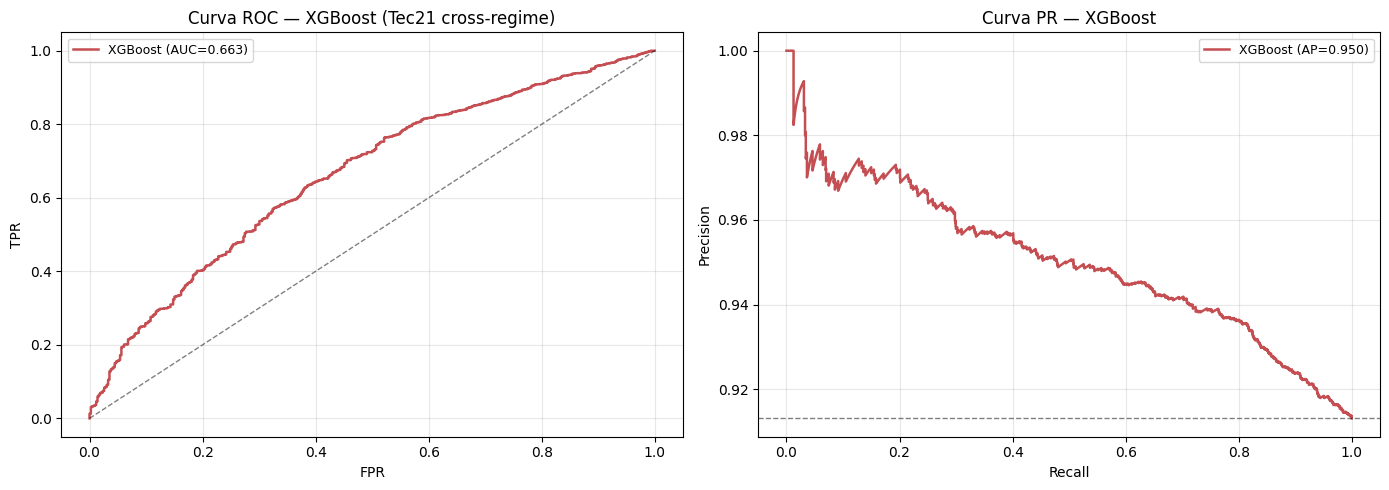

✓ Figuras guardadas


In [12]:
if XGB_AVAILABLE and results_final:
    res_xgb = results_final[0]
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_te_tec, res_xgb['y_pred'], normalize='true')
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Desertor','Retenido']
                           ).plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'XGBoost  AUC={res_xgb["auc"]:.3f}')
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fpr, tpr, _ = roc_curve(y_te_tec, res_xgb['y_proba'])
    axes[0].plot(fpr, tpr, color='#C44E52', lw=1.8,
                 label=f'XGBoost (AUC={res_xgb["auc"]:.3f})')
    axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('Curva ROC — XGBoost (Tec21 cross-regime)')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    prec_c, rec_c, _ = precision_recall_curve(y_te_tec, res_xgb['y_proba'])
    ap = average_precision_score(y_te_tec, res_xgb['y_proba'])
    axes[1].plot(rec_c, prec_c, color='#C44E52', lw=1.8,
                 label=f'XGBoost (AP={ap:.3f})')
    axes[1].axhline(y_te_tec.mean(), color='k', ls='--', lw=1, alpha=0.5)
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Curva PR — XGBoost')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'xgb_roc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Figuras guardadas')
else:
    print('XGBoost no disponible — sin figuras.')
